[]

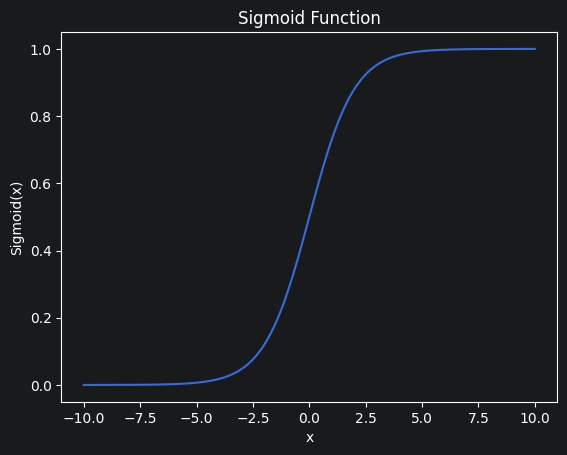

In [1]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-10, 10, 100)


def sigmoid(x):
    return 1 / (1 + np.exp(-x))


y = sigmoid(x)
plt.plot(x, y)
plt.title('Sigmoid Function')
plt.xlabel('x')
plt.ylabel('Sigmoid(x)')
plt.plot()

Derivative of sigmoid function wrt z

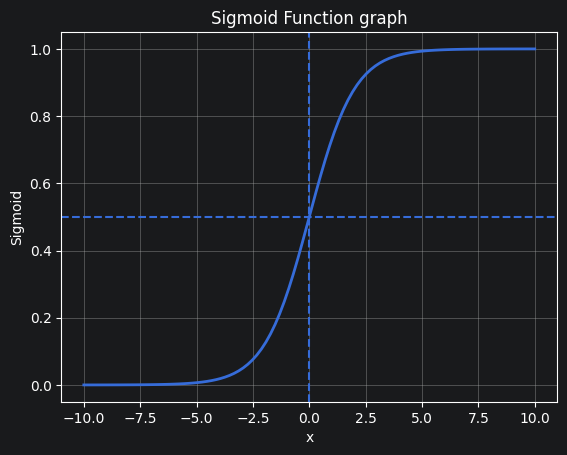

In [2]:
plt.plot(x, y, linewidth = 2, label='Sigmoid Curve')
plt.axhline(y=0.5,linestyle = '--',label ='y=0.5')
plt.axvline(x=0, linestyle='--', label='x=0')
plt.title("Sigmoid Function graph")
plt.xlabel('x')
plt.ylabel('Sigmoid')
plt.grid(True)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

y_pred = np.linspace(0.01, 0.99, 100)
y_pred

array([0.01      , 0.01989899, 0.02979798, 0.03969697, 0.04959596,
       0.05949495, 0.06939394, 0.07929293, 0.08919192, 0.09909091,
       0.1089899 , 0.11888889, 0.12878788, 0.13868687, 0.14858586,
       0.15848485, 0.16838384, 0.17828283, 0.18818182, 0.19808081,
       0.2079798 , 0.21787879, 0.22777778, 0.23767677, 0.24757576,
       0.25747475, 0.26737374, 0.27727273, 0.28717172, 0.29707071,
       0.3069697 , 0.31686869, 0.32676768, 0.33666667, 0.34656566,
       0.35646465, 0.36636364, 0.37626263, 0.38616162, 0.39606061,
       0.4059596 , 0.41585859, 0.42575758, 0.43565657, 0.44555556,
       0.45545455, 0.46535354, 0.47525253, 0.48515152, 0.49505051,
       0.50494949, 0.51484848, 0.52474747, 0.53464646, 0.54454545,
       0.55444444, 0.56434343, 0.57424242, 0.58414141, 0.5940404 ,
       0.60393939, 0.61383838, 0.62373737, 0.63363636, 0.64353535,
       0.65343434, 0.66333333, 0.67323232, 0.68313131, 0.6930303 ,
       0.70292929, 0.71282828, 0.72272727, 0.73262626, 0.74252

In [4]:
loss_y1 = -np.log(y_pred)
loss_y0 = -np.log(1-y_pred)

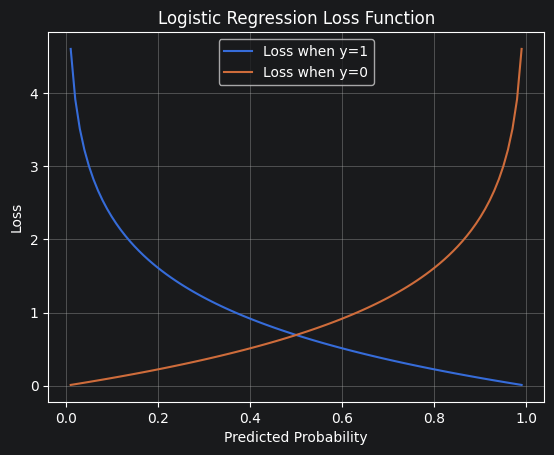

In [5]:
plt.plot(y_pred,loss_y1,label ="Loss when y=1")
plt.plot(y_pred, loss_y0, label="Loss when y=0")
plt.title("Logistic Regression Loss Function")
plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

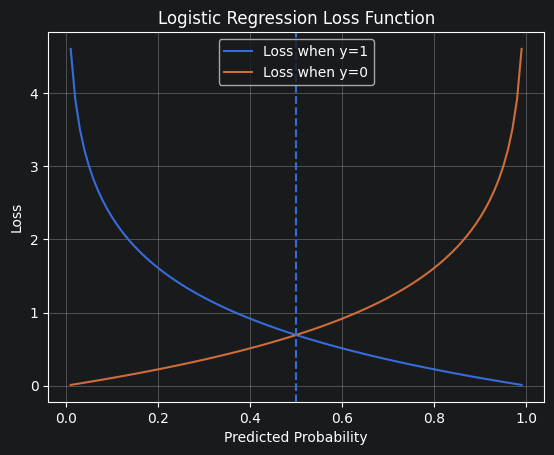

In [6]:
plt.plot(y_pred, loss_y1, label="Loss when y=1")
plt.plot(y_pred, loss_y0, label="Loss when y=0")
plt.title("Logistic Regression Loss Function")
plt.xlabel("Predicted Probability")
plt.ylabel("Loss")
plt.axvline(x=0.5,linestyle='--')
plt.grid(True)
plt.legend()
plt.show()

In [7]:
import numpy as np
predictions =[0.01,0.1,0.5,0.9,0.99]

In [8]:
print("When acual y = 1")
for p in predictions:
    loss = -np.log(p)
    print(f"Predictions: {p}, Loss :{loss:.4f}")

When acual y = 1
Predictions: 0.01, Loss :4.6052
Predictions: 0.1, Loss :2.3026
Predictions: 0.5, Loss :0.6931
Predictions: 0.9, Loss :0.1054
Predictions: 0.99, Loss :0.0101


In [9]:
print("When acual y = 0")
for p in predictions:
    loss = -np.log(1- p)
    print(f"Predictions: {p}, Loss :{loss:.4f}")

When acual y = 0
Predictions: 0.01, Loss :0.0101
Predictions: 0.1, Loss :0.1054
Predictions: 0.5, Loss :0.6931
Predictions: 0.9, Loss :2.3026
Predictions: 0.99, Loss :4.6052


In [10]:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self,learning_rate = 0.01, iterations =1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
    def fit(self,X,y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.iterations):
            linear_output = np.dot(X,self.weights)+self.bias
            y_pred = self.sigmoid(linear_output)


In [11]:
model = LogisticRegressionScratch(learning_rate=0.01,iterations=2000)

In [12]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=1000,
                           n_features=2,
                           n_informative=2,
                           n_redundant=0,
                           n_classes=2,
                           random_state=45)

In [13]:
X.shape

(1000, 2)

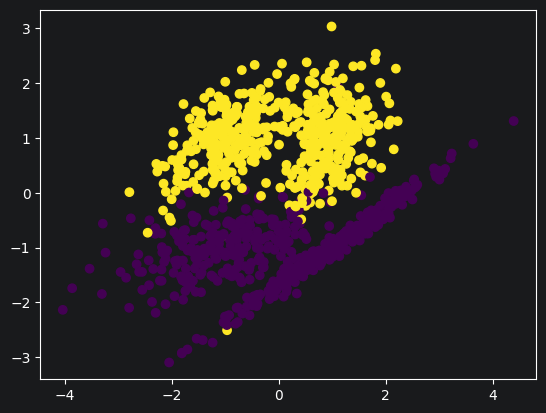

In [14]:
plt.scatter(X[:,0],X[:,1],c=y)

In [15]:
import numpy as np

class LogisticRegressionScratch:
    def __init__(self,learning_rate = 0.01, iterations =1000):
        self.learning_rate = learning_rate
        self.iterations = iterations
        self.weights = None
        self.bias = None
        self.cost_history = []

    def sigmoid(self,z):
        return 1/(1+np.exp(-z))
    def compute_cost(self,y,y_pred):
        m = len(y)
        epsilon = 1e-9
        cost = -(1/m)*np.sum(y*np.log(y_pred+epsilon)+(1-y)*np.log(1-y_pred+epsilon))
        return cost
    def fit(self,X,y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0
        for i in range(self.iterations):
            linear_output = np.dot(X,self.weights)+self.bias
            y_pred = self.sigmoid(linear_output)
            cost = self.compute_cost(y,y_pred)
            self.cost_history.append(cost)
            dw = (1/n_samples)*np.dot(X.T,(y_pred-y))
            db =  (1/n_samples)* np.sum(y_pred-y)
            self.weights = self.weights - self.learning_rate*dw
            self.bias = self.bias - self.learning_rate*db
            print(self.weights,self.bias)
    def predict_proba(self,X):
        linear_output = np.dot(X,self.weights) + self.bias
        return self.sigmoid(linear_output)

    def predict(self,X):
        probabilities = self.predict_proba(X)
        return np.array([1 if p>=0.5 else 0 for p in probabilities])

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler

In [17]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size = 0.2,random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [18]:
model = LogisticRegressionScratch(learning_rate=0.01,iterations=2000)
model.fit(X_train,y_train)

[9.69556119e-06 4.24571246e-03] -1.25e-05
[1.71694414e-05 8.48080566e-03] -2.496875078163276e-05
[2.24327478e-05 1.27053075e-02] -3.7406335116773646e-05
[2.54966009e-05 1.69192459e-02] -4.98128401068746e-05
[2.63721333e-05 2.11226490e-02] -6.218835705030551e-05
[2.50704891e-05 2.53155451e-02] -7.453298131083523e-05
[2.16028217e-05 2.94979623e-02] -8.684681218728687e-05
[1.59802938e-05 3.36699292e-02] -9.912995278440345e-05
[8.21407535e-06 3.78314742e-02] -0.00011138250988495557
[-1.68465726e-06  4.19826258e-02] -0.00012360459382312468
[-1.37047222e-05  4.61234128e-02] -0.00013579631835919075
[-2.78349335e-05  5.02538639e-02] -0.0001479578005555539
[-4.40641020e-05  5.43740079e-02] -0.00016008916065411765
[-6.23810365e-05  5.84838737e-02] -0.00017219052195505986
[-8.27745449e-05  6.25834904e-02] -0.00018426201069701525
[-0.00010523  0.06667289] -0.00019630375593869418
[-0.00012975  0.07075209] -0.00020831588944195866
[-0.0001563   0.07482114] -0.00022029854555637656
[-0.00018489  0.0788

In [19]:
y_pred = model.predict(X_test)

In [20]:
accuracy = accuracy_score(y_test,y_pred)

In [21]:
accuracy

0.96

In [22]:
model.weights,model.bias

(array([-0.39887502,  2.6649161 ]), np.float64(0.017712667380383906))